# Emotion Classification in Text

In this notebook I build models that predict emotions from short text.
The labels are `anger`, `fear`, `joy`, `love`, `sad`, and `surprise`.


![Project Image](img.jpg)

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

project_custom_stop_words = {
    "feel", "feeling", "im", "like", "just", "really", "know", "time",
    "little", "people", "want", "think", "ive", "bit", "things"
}
project_stop_words = list(ENGLISH_STOP_WORDS.union(project_custom_stop_words))


## Domain Understanding

This project is in NLP (Natural Language Processing).
The goal is to read a text message and classify it into one emotion label.


### Emotion Labels Used

The dataset in this project uses these labels:
- anger
- fear
- joy
- love
- sad
- surprise


### Why This Task Is Tricky

Emotion is subjective, so two people can read the same sentence and feel different emotions.
The dataset still uses one strict label per message because the model needs fixed targets during training.
Text also has no voice tone or facial expression, which makes emotion detection harder.


### Why I Show Emotion Percentages

At prediction time, I prefer showing a spread of percentages across emotions instead of only one hard label.
This reflects uncertainty better and is more realistic for mixed or unclear messages.
The top percentage is still used as the final predicted label.


### Applications and Limits

Emotion detection can help with social media analysis, customer feedback, and chatbot improvement.
But because emotion is subjective, results should be used carefully and not treated as absolute truth.


## Data Preparation


### Importing the Dataset

Here I load the main CSV file.
The raw file stays untouched and all processing is done in this notebook.


In [2]:
df = pd.read_csv("combined_emotion.csv")

# Basic column cleanup and label normalization.
df["sentence"] = df["sentence"].astype(str).str.strip()
df["emotion"] = (
    df["emotion"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"suprise": "surprise"})
)

# Remove rows missing required values.
df = df[(df["sentence"] != "") & (df["emotion"] != "")].reset_index(drop=True)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_sentence"] = df["sentence"].apply(clean_text)

df.head()


,sentence,emotion,clean_sentence
0,i just feel really helpless and heavy hearted,fear,i just feel really helpless and heavy hearted
1,ive enjoyed being able to slouch about relax a...,sad,ive enjoyed being able to slouch about relax a...
2,i gave up my internship with the dmrg and am f...,fear,i gave up my internship with the dmrg and am f...
3,i dont know i feel so lost,sad,i dont know i feel so lost
4,i am a kindergarten teacher and i am thoroughl...,fear,i am a kindergarten teacher and i am thoroughl...


### Cleaning Labels and Balancing

I removed duplicate sentences first, then fixed label names, then balanced the classes.
In this run, 28,924 duplicates were removed.
Each emotion ended at 12,407 rows, so the final working dataset is 74,442 rows.


In [3]:
rows_before = len(df)
df = df.drop_duplicates(subset=["clean_sentence"]).reset_index(drop=True)
rows_after = len(df)

print(f"Removed {rows_before - rows_after} duplicate sentences.")
print(f"Rows after deduplication: {rows_after}")

# Downsample each class to the smallest class size.
target_size = df["emotion"].value_counts().min()

df = (
    df.groupby("emotion", group_keys=False)
      .sample(n=target_size, random_state=42)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(f"Balanced rows per label: {target_size}")
print(df["emotion"].value_counts())


Removed 28924 duplicate sentences.
Rows after deduplication: 393822
Balanced rows per label: 12407
emotion
anger       12407
joy         12407
sad         12407
surprise    12407
fear        12407
love        12407
Name: count, dtype: int64


### Dataset Check

`df.info()` shows 74,442 rows and no missing values in `sentence`, `emotion`, or `clean_sentence`.
The label counts are fully balanced: anger, fear, joy, love, sad, and surprise are all 12,407.


In [4]:
df.info()
df["emotion"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 74442 entries, 0 to 74441
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   sentence        74442 non-null  str  
 1   emotion         74442 non-null  str  
 2   clean_sentence  74442 non-null  str  
dtypes: str(3)
memory usage: 1.7 MB


emotion
anger       12407
joy         12407
sad         12407
surprise    12407
fear        12407
love        12407
Name: count, dtype: int64

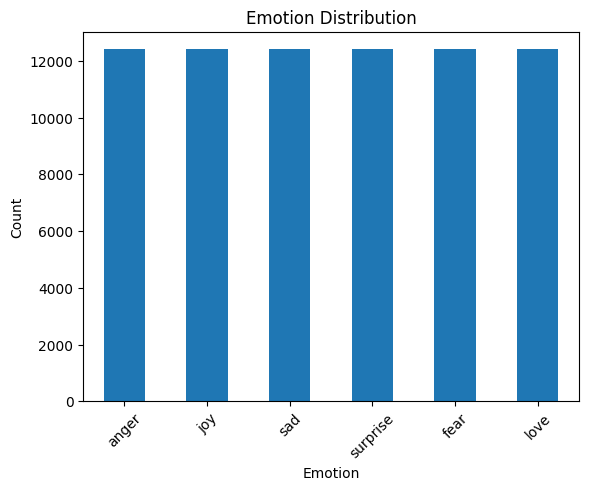

In [5]:
import matplotlib.pyplot as plt

df["emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

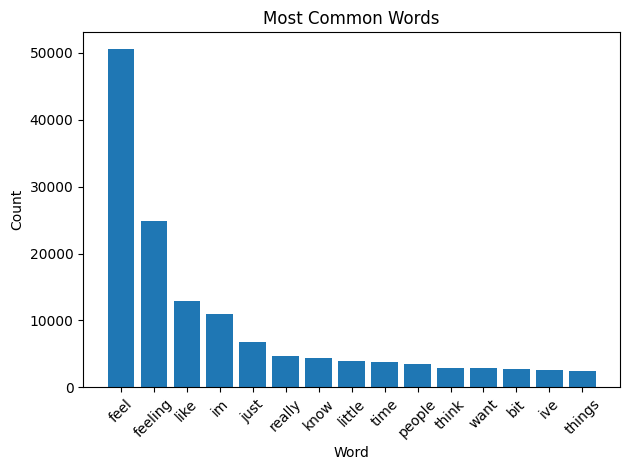

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

cv = CountVectorizer(stop_words="english", max_features=15)
word_counts = cv.fit_transform(df["clean_sentence"].fillna(""))
word_sums = word_counts.sum(axis=0).A1

words_df = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": word_sums
}).sort_values("count", ascending=False)

plt.bar(words_df["word"], words_df["count"])
plt.title("Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Most Common Words per Emotion

This shows the top words inside each emotion label separately.
For this view I use a light cleanup on the original sentence text so words stay separated.
I also remove common filler words that appear in many labels (`feel`, `feeling`, `little`, `people`, `want`, `think`, `ive`, `bit`, `things`) so the top terms are more meaningful.


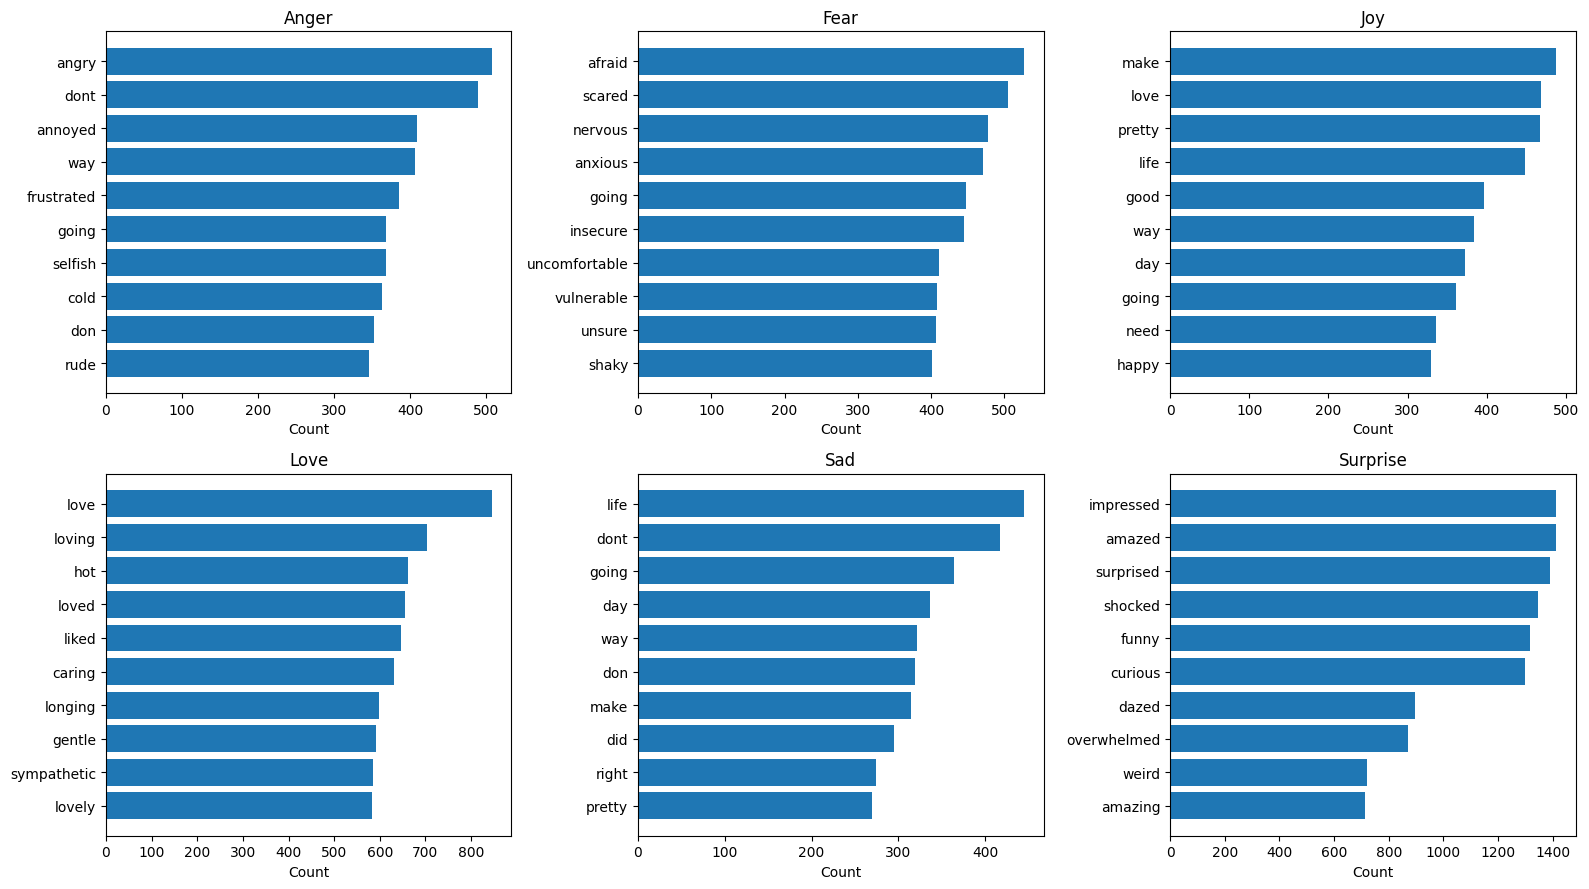

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Build a simple text version for word-frequency analysis only.
word_df = df[["emotion", "sentence"]].copy()
word_df["word_text"] = (
    word_df["sentence"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
word_df = word_df[word_df["word_text"] != ""].copy()

top_n = 10
top_rows = []

for emotion in sorted(word_df["emotion"].unique()):
    texts = word_df.loc[word_df["emotion"] == emotion, "word_text"]

    cv_label = CountVectorizer(stop_words=project_stop_words, max_features=3000)
    counts = cv_label.fit_transform(texts)
    sums = counts.sum(axis=0).A1
    words = cv_label.get_feature_names_out()

    top_idx = np.argsort(sums)[::-1][:top_n]
    for idx in top_idx:
        top_rows.append({
            "emotion": emotion,
            "word": words[idx],
            "count": int(sums[idx]),
        })

top_words_df = pd.DataFrame(top_rows)

emotions = sorted(top_words_df["emotion"].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=False)
axes = axes.flatten()

for ax, emotion in zip(axes, emotions):
    sub = top_words_df[top_words_df["emotion"] == emotion].sort_values("count")
    ax.barh(sub["word"], sub["count"])
    ax.set_title(emotion.capitalize())
    ax.set_xlabel("Count")

for ax in axes[len(emotions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### Sentence Length by Emotion

This graph compares message length across emotions using word counts.
I use this to check if some labels are naturally longer or shorter, which can affect classification.


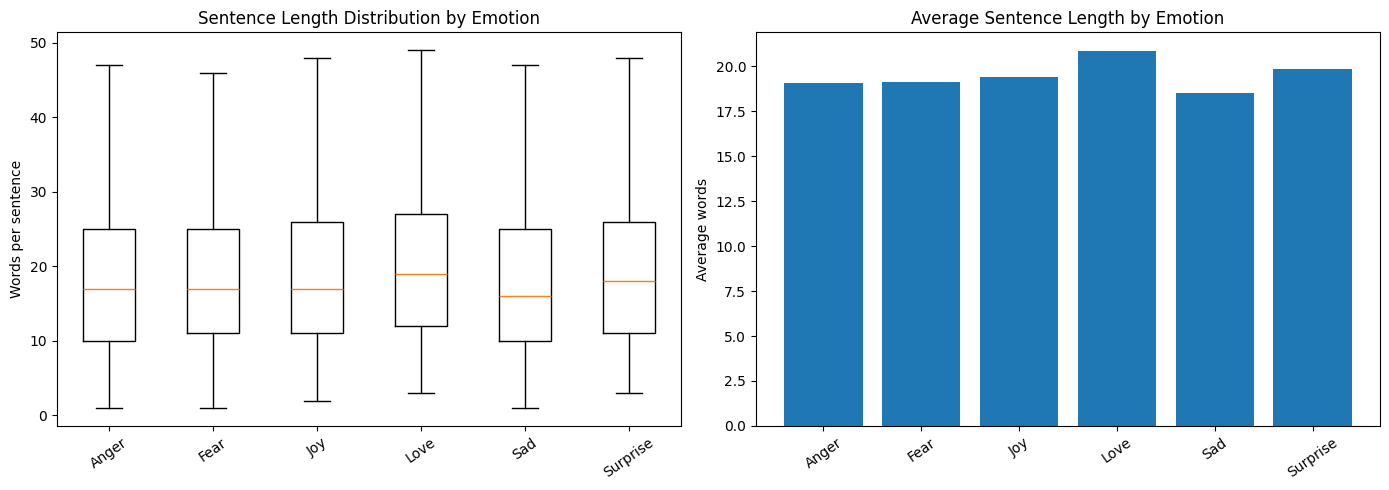

In [8]:
import matplotlib.pyplot as plt

length_df = df[["emotion", "sentence"]].copy()
length_df["word_count"] = length_df["sentence"].astype(str).str.split().str.len()

emotion_order = sorted(length_df["emotion"].unique())
box_data = [
    length_df.loc[length_df["emotion"] == emo, "word_count"].values
    for emo in emotion_order
]

mean_lengths = length_df.groupby("emotion")["word_count"].mean().reindex(emotion_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(box_data, tick_labels=[e.capitalize() for e in emotion_order], showfliers=False)
axes[0].set_title("Sentence Length Distribution by Emotion")
axes[0].set_ylabel("Words per sentence")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar([e.capitalize() for e in emotion_order], mean_lengths.values)
axes[1].set_title("Average Sentence Length by Emotion")
axes[1].set_ylabel("Average words")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


In this run, the overall average is about 19.41 words per sentence (median 17).
`love` is the longest on average (~20.79 words) and `sad` is the shortest (~18.57 words).
The differences are not huge, so sentence length alone is not enough to separate emotions.


### Text Cleaning

I lowercased the text, removed punctuation/noise, and fixed extra spaces.
This gives cleaner tokens before vectorization and helps the models stay consistent.


In [9]:
# Preview original vs cleaned text.
df[["sentence", "clean_sentence"]].head()

,sentence,clean_sentence
0,i feel like being bitchy and cursing him or so...,i feel like being bitchy and cursing him or so...
1,im happy to be back blogging however and feeli...,im happy to be back blogging however and feeli...
2,im knitting a size up since i havent lost the ...,im knitting a size up since i havent lost the ...
3,i love thinking up recipes starting with one i...,i love thinking up recipes starting with one i...
4,ive taken the lortab twice today and think the...,ive taken the lortab twice today and think the...


### Train, Validation, and Test Split

I used stratified splitting so class ratios stay equal in every split.
This run produced 37,221 train samples, 22,332 validation samples, and 14,889 test samples.


In [10]:
X = df["clean_sentence"]
y = df["emotion"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.40, random_state=42, stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 37221
Validation samples: 22332
Test samples: 14889


### Feature Extraction (TF-IDF)

I converted text to TF-IDF vectors with stop-word filtering and `max_df`/`min_df`.
The training matrix shape is `(37221, 5000)`, so we use 5,000 text features per sample.


In [11]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=project_stop_words,
    max_df=0.85,
    min_df=2
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_vec.shape)


TF-IDF shape: (37221, 5000)


### Reproducibility Notes

I use `random_state=42` in balancing and splitting so results are reproducible.
I also use the same `project_stop_words` list in both TF-IDF and the common-word graph, so analysis and training stay consistent.
If preprocessing changes (for example stop words), I rerun from the split/vectorization step onward so reported metrics stay correct.


## Modelling and Evaluation


In this section I train three models and evaluate each one the same way so the comparison is fair.


Because the dataset is balanced, macro scores and weighted scores are very close in this run.


### KNN Model (Baseline)

I start with KNN as a baseline model using `k=29` and cosine distance.


In [12]:
knn_model = KNeighborsClassifier(n_neighbors=29, metric="cosine")

knn_model.fit(X_train_vec, y_train)
print("KNN trained with k=29")


KNN trained with k=29


#### KNN Validation Evaluation

KNN reached about 0.88 accuracy and 0.88 macro F1 on validation.
So it works decently, but it is clearly not the strongest model yet.


In [13]:
y_val_pred_knn = knn_model.predict(X_val_vec)

print(classification_report(y_val, y_val_pred_knn))


              precision    recall  f1-score   support

       anger       0.90      0.89      0.90      3722
        fear       0.88      0.88      0.88      3722
         joy       0.88      0.84      0.86      3722
        love       0.88      0.91      0.90      3722
         sad       0.91      0.87      0.89      3722
    surprise       0.85      0.91      0.88      3722

    accuracy                           0.88     22332
   macro avg       0.88      0.88      0.88     22332
weighted avg       0.88      0.88      0.88     22332



#### KNN Test Evaluation

On test, KNN got 0.8783 accuracy and 0.8783 macro F1.
Validation and test are close, so the model is stable, just lower than the other two models.


In [14]:
y_test_pred_knn = knn_model.predict(X_test_vec)

print(classification_report(y_test, y_test_pred_knn))


              precision    recall  f1-score   support

       anger       0.90      0.89      0.90      2481
        fear       0.87      0.89      0.88      2481
         joy       0.88      0.83      0.85      2482
        love       0.87      0.90      0.88      2482
         sad       0.91      0.87      0.89      2482
    surprise       0.83      0.89      0.86      2481

    accuracy                           0.88     14889
   macro avg       0.88      0.88      0.88     14889
weighted avg       0.88      0.88      0.88     14889



#### KNN Confusion Matrix

The matrix has a clear diagonal, but confusion is still visible between some close emotions.
This matches the lower overall score compared with Logistic Regression and SVM.


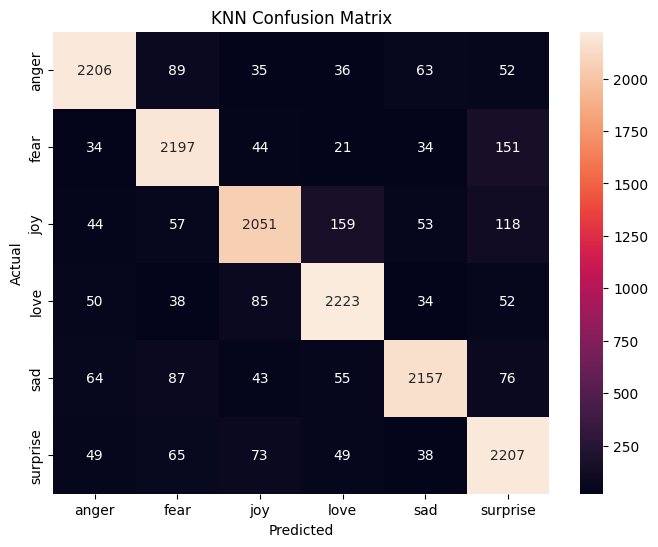

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(knn_model.classes_)
cm_knn = confusion_matrix(y_test, y_test_pred_knn, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()


#### KNN Performance per Emotion

KNN is weakest on `joy` recall (0.83) and `surprise` precision (0.84).
Most other class F1 values are around 0.87 to 0.89.


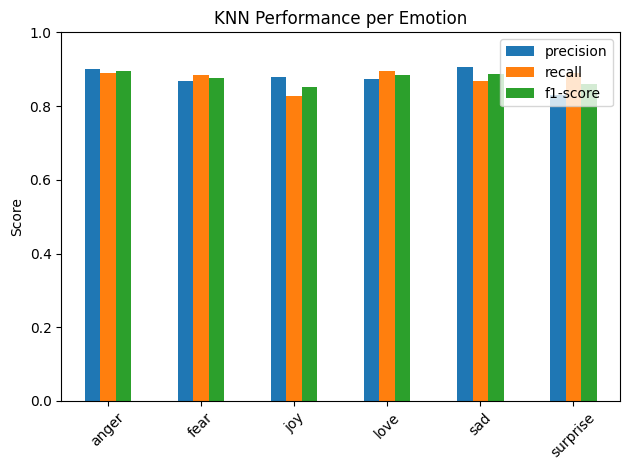

In [16]:
report_knn = classification_report(y_test, y_test_pred_knn, output_dict=True)
report_knn_df = pd.DataFrame(report_knn).transpose()

report_knn_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("KNN Performance per Emotion")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Logistic Regression Model

Now I train Logistic Regression, which is usually strong for TF-IDF text data.


In [17]:
lr_model = LogisticRegression(max_iter=200)

lr_model.fit(X_train_vec, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Logistic Regression Validation Evaluation

Logistic Regression reached about 0.93 accuracy and 0.93 macro F1 on validation.
That is a clear jump over KNN.


In [18]:
y_val_pred_lr = lr_model.predict(X_val_vec)

print(classification_report(y_val, y_val_pred_lr))


              precision    recall  f1-score   support

       anger       0.94      0.93      0.93      3722
        fear       0.92      0.90      0.91      3722
         joy       0.90      0.90      0.90      3722
        love       0.94      0.96      0.95      3722
         sad       0.94      0.91      0.92      3722
    surprise       0.92      0.97      0.94      3722

    accuracy                           0.93     22332
   macro avg       0.93      0.93      0.93     22332
weighted avg       0.93      0.93      0.93     22332



#### Logistic Regression Test Evaluation

On test, Logistic Regression got 0.9277 accuracy and 0.9275 macro F1.
So it improves test accuracy by about 5 points compared with KNN.


In [19]:
y_test_pred_lr = lr_model.predict(X_test_vec)

print(classification_report(y_test, y_test_pred_lr))


              precision    recall  f1-score   support

       anger       0.95      0.91      0.93      2481
        fear       0.92      0.90      0.91      2481
         joy       0.91      0.90      0.91      2482
        love       0.94      0.96      0.95      2482
         sad       0.93      0.92      0.92      2482
    surprise       0.92      0.97      0.94      2481

    accuracy                           0.93     14889
   macro avg       0.93      0.93      0.93     14889
weighted avg       0.93      0.93      0.93     14889



#### Logistic Regression Confusion Matrix

This matrix is tighter on the diagonal than KNN.
`surprise` recall is very high (0.97), and most classes stay around low-to-mid 0.90 scores.


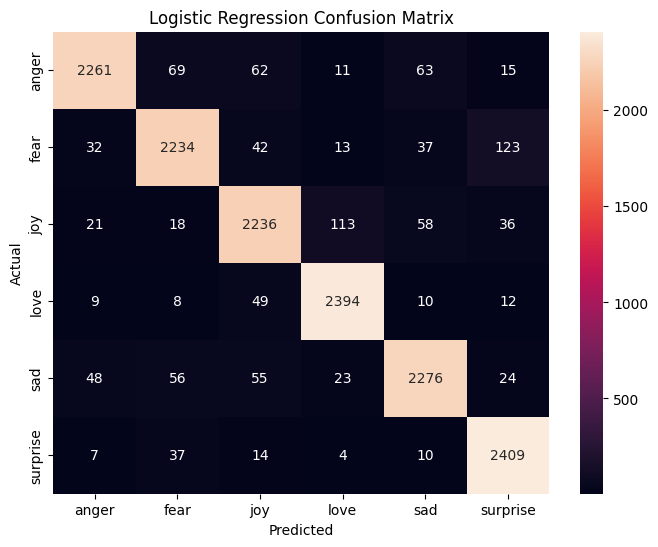

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(lr_model.classes_)
cm_lr = confusion_matrix(y_test, y_test_pred_lr, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


#### Logistic Regression Performance per Emotion

Class F1 scores are strong and consistent, roughly from 0.90 to 0.95.
This is much more balanced across labels than the KNN baseline.


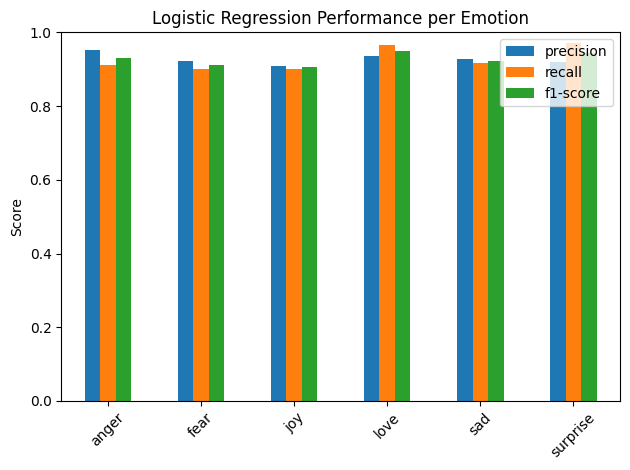

In [21]:
report_lr = classification_report(y_test, y_test_pred_lr, output_dict=True)
report_lr_df = pd.DataFrame(report_lr).transpose()

report_lr_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("Logistic Regression Performance per Emotion")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### SVM Model

Here I train a linear SVM, another strong baseline for sparse text features.


In [22]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train_vec, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

#### SVM Validation Evaluation

SVM also reached about 0.93 accuracy and 0.93 macro F1 on validation.
So before final test, it already looked as strong as Logistic Regression.


In [23]:
y_val_pred_svm = svm_model.predict(X_val_vec)

print(classification_report(y_val, y_val_pred_svm))


              precision    recall  f1-score   support

       anger       0.94      0.93      0.93      3722
        fear       0.92      0.90      0.91      3722
         joy       0.91      0.90      0.91      3722
        love       0.93      0.95      0.94      3722
         sad       0.93      0.91      0.92      3722
    surprise       0.93      0.96      0.95      3722

    accuracy                           0.93     22332
   macro avg       0.93      0.93      0.93     22332
weighted avg       0.93      0.93      0.93     22332



#### SVM Test Evaluation

On test, SVM got 0.9297 accuracy and 0.9295 macro F1.
That is the best result in this notebook, but only slightly above Logistic Regression.


In [24]:
y_test_pred_svm = svm_model.predict(X_test_vec)

print(classification_report(y_test, y_test_pred_svm))


              precision    recall  f1-score   support

       anger       0.95      0.92      0.94      2481
        fear       0.92      0.90      0.91      2481
         joy       0.91      0.90      0.91      2482
        love       0.94      0.96      0.95      2482
         sad       0.93      0.92      0.92      2482
    surprise       0.93      0.97      0.95      2481

    accuracy                           0.93     14889
   macro avg       0.93      0.93      0.93     14889
weighted avg       0.93      0.93      0.93     14889



#### SVM Confusion Matrix

SVM gives one of the cleanest diagonals overall.
It especially keeps strong recall for `surprise` (0.97) while staying stable on other classes.


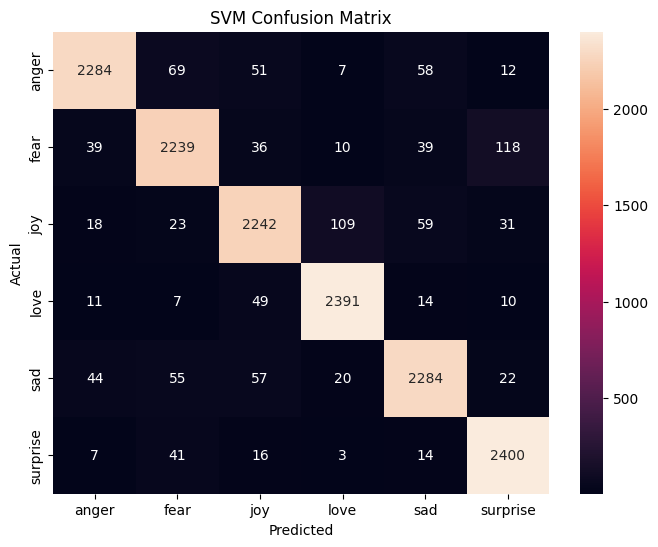

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = list(svm_model.classes_)
cm_svm = confusion_matrix(y_test, y_test_pred_svm, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()


#### SVM Performance per Emotion

SVM class F1 values are around 0.91 to 0.95.
`love` and `surprise` are the strongest classes, while `fear`/`joy` are a bit lower but still solid.


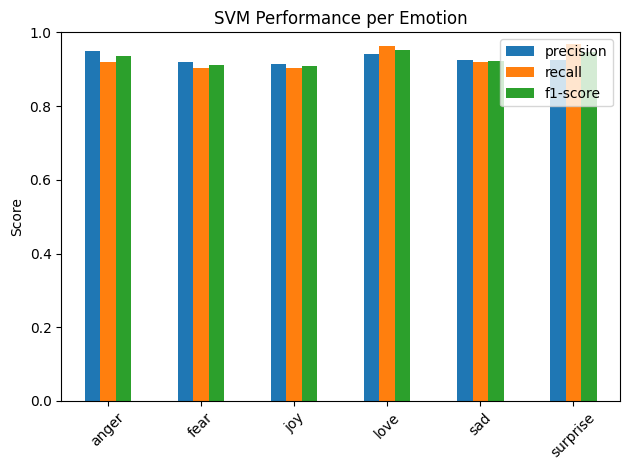

In [26]:
report_svm = classification_report(y_test, y_test_pred_svm, output_dict=True)
report_svm_df = pd.DataFrame(report_svm).transpose()

report_svm_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")
plt.title("SVM Performance per Emotion")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Model Comparison

Final test ranking in this run is:
1. SVM: accuracy 0.9297, macro F1 0.9295
2. Logistic Regression: accuracy 0.9277, macro F1 0.9275
3. KNN: accuracy 0.8783, macro F1 0.8783

SVM wins, but Logistic Regression is very close.


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,SVM,0.9295,0.9296,0.9295,0.9294,0.9294
1,Logistic Regression,0.9275,0.9277,0.9275,0.9273,0.9273
2,KNN,0.8759,0.8768,0.8759,0.8759,0.8759


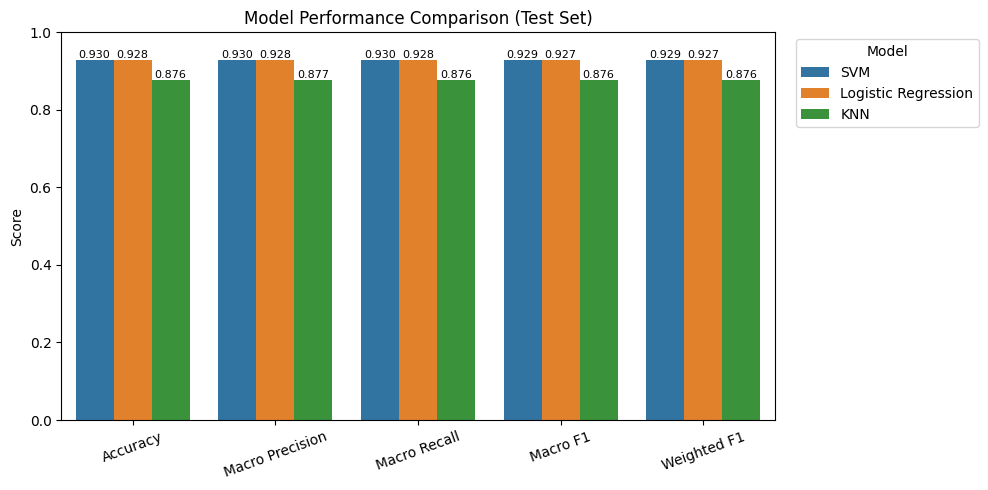

In [27]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

model_predictions = {
    "KNN": y_test_pred_knn,
    "Logistic Regression": y_test_pred_lr,
    "SVM": y_test_pred_svm,
}

comparison_rows = []

for model_name, y_pred in model_predictions.items():
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    comparison_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro Precision": p_macro,
        "Macro Recall": r_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
display(comparison_df.round(4))

plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model")
ax.set_title("Model Performance Comparison (Test Set)")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()
plt.show()


### How I Read These Metrics

Because the dataset is balanced, Accuracy and Macro F1 are close.
I still focus mainly on Macro F1 and per-emotion charts, not only one score, before picking the final model.


### Custom Text Check (SVM)

This check uses the trained SVM model for a custom sentence.
The percentages below are based on normalized SVM decision scores (not calibrated probabilities).


In [28]:
custom_text = "Have a nice day"

cleaned = clean_text(custom_text)
text_vec = vectorizer.transform([cleaned])

scores = svm_model.decision_function(text_vec)[0]
classes = svm_model.classes_

exp_scores = np.exp(scores - np.max(scores))
score_share = exp_scores / exp_scores.sum()

ranked = sorted(zip(classes, score_share), key=lambda x: x[1], reverse=True)

print("Text:", custom_text)
print("\nEmotion score spread (SVM):")
for emotion, p in ranked:
    print(f"{emotion:10s} {p * 100:.2f}%")

print("\nPredicted emotion:", ranked[0][0])


Text: Have a nice day

Emotion score spread (SVM):
joy        32.24%
sad        27.82%
fear       14.83%
anger      11.39%
surprise   7.74%
love       5.98%

Predicted emotion: joy


## Conclusion

In this project I built and compared three text-classification models for emotion detection.
I prepared the data by cleaning labels, removing duplicates, balancing the classes, and creating TF-IDF features with a shared stop-word setup.
I also explored the dataset with distribution, word-frequency, and sentence-length analysis to understand how the labels differ.

Based on the final comparison, SVM gave the best overall performance on this dataset, with Logistic Regression close behind and KNN lower.

I think the key step to improve this model further is more data with more varied language use.
That should help the model handle different writing styles, expressions, and edge cases better.
